Near Adiabatic Return to Ground State
===============================

The Matt Chow (MC) gate style takes advantage of a surprisingly consistent return to ground state. We want to understand why this happens. We know that if we go too fast, the MC gate does not work, and if we goo very slow we are in the adiabatic regime where we expect this to happen. We will explore the "near-adiabatic" regime.

First some code that is originally from the [./pulses_test.ipynb](./pulses_test.ipynb) file:

In [1]:
using QuantumOptics
using LinearAlgebra
using Interpolations
using CairoMakie

computational = SpinBasis(1//2)

I = identityoperator(computational)
σx = sigmax(computational)
σy = sigmay(computational)
σz = sigmaz(computational)
σ_vec = [σx, σy, σz];

down = spindown(computational)
up = spinup(computational)


function twoLevelSysFromParameters(Δ::Function, Ω::Function, ϕ::Function, T::Real; number_of_reported_times::Int = 100)
    
    H(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, number_of_reported_times)
    tout, psi_t = timeevolution.schroedinger_dynamic(tspan, down, H)
    return tout, psi_t, H
end


function mattChow(T::Real, Ω_scaling=1)
    fudge_factor = 1.65 # this was not part of the original gate but is needed for the simulation to match the experimental data
    Ω_points = fudge_factor*2π .* [0.0, 0.412, 0.825, 1.237, 1.485, 1.485, 1.237, 0.825, 0.412, 0.0]
    Δ_points = 2π .* [4.08, 3.06, 2.04, 1.02, 0.408, 0.408, 1.02, 2.04, 3.06, 4.08]

    ts = range(0, T, length(Ω_points))
    Δ(t) = cubic_spline_interpolation(ts, Δ_points)(t) # this could also be `Ω = cubic_spline_interpolation(ts, Ω_points)` ¯\_(ツ)_/¯
    Ω(t) = cubic_spline_interpolation(ts, Ω_points)(t) * Ω_scaling
    ϕ(t) = 0

    (tout, psi_t, H) = twoLevelSysFromParameters(Δ, Ω, ϕ, T)
    return (tout, psi_t, H), (Δ, Ω, ϕ) # returns a lot of stuff but they are all useful
end
;

Now if we look at the MC gate over time we see the efficiency of returning to the ground state:

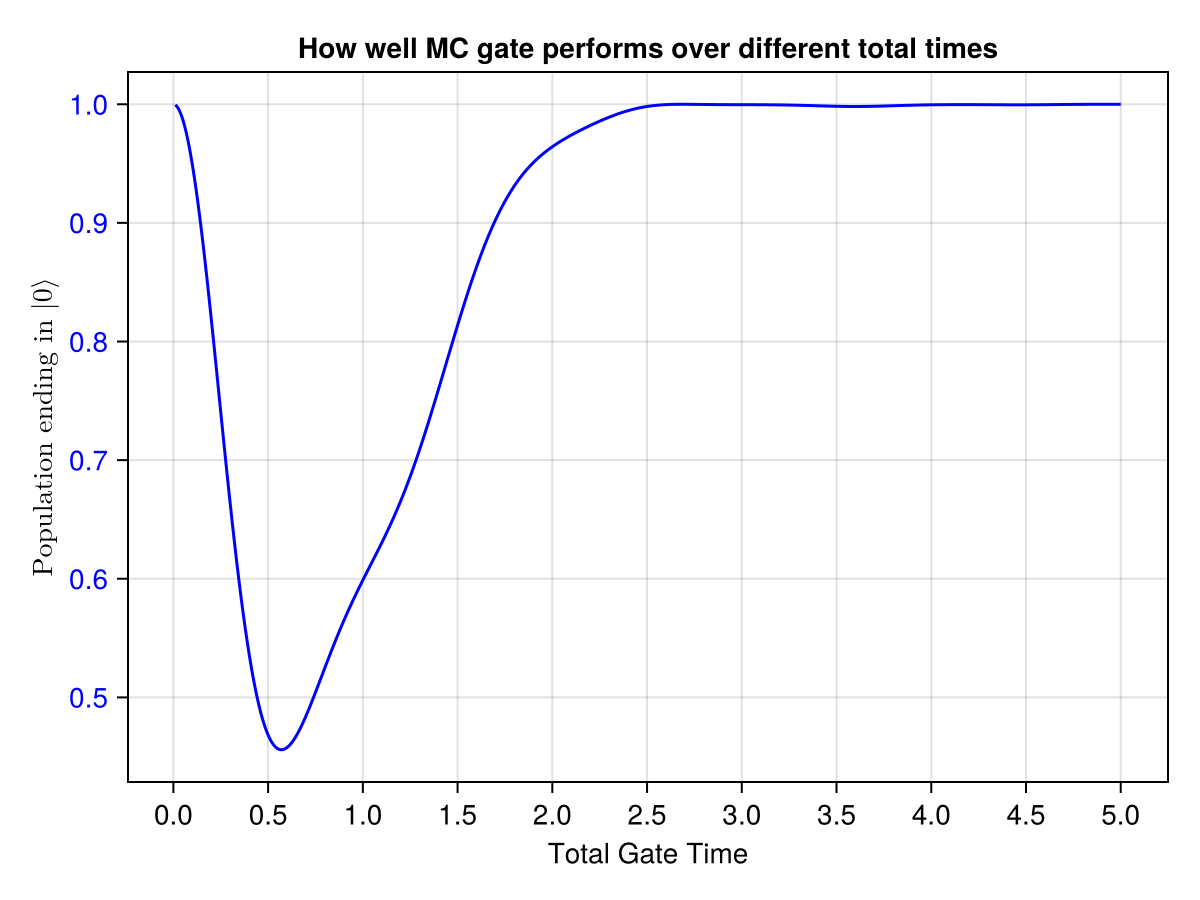

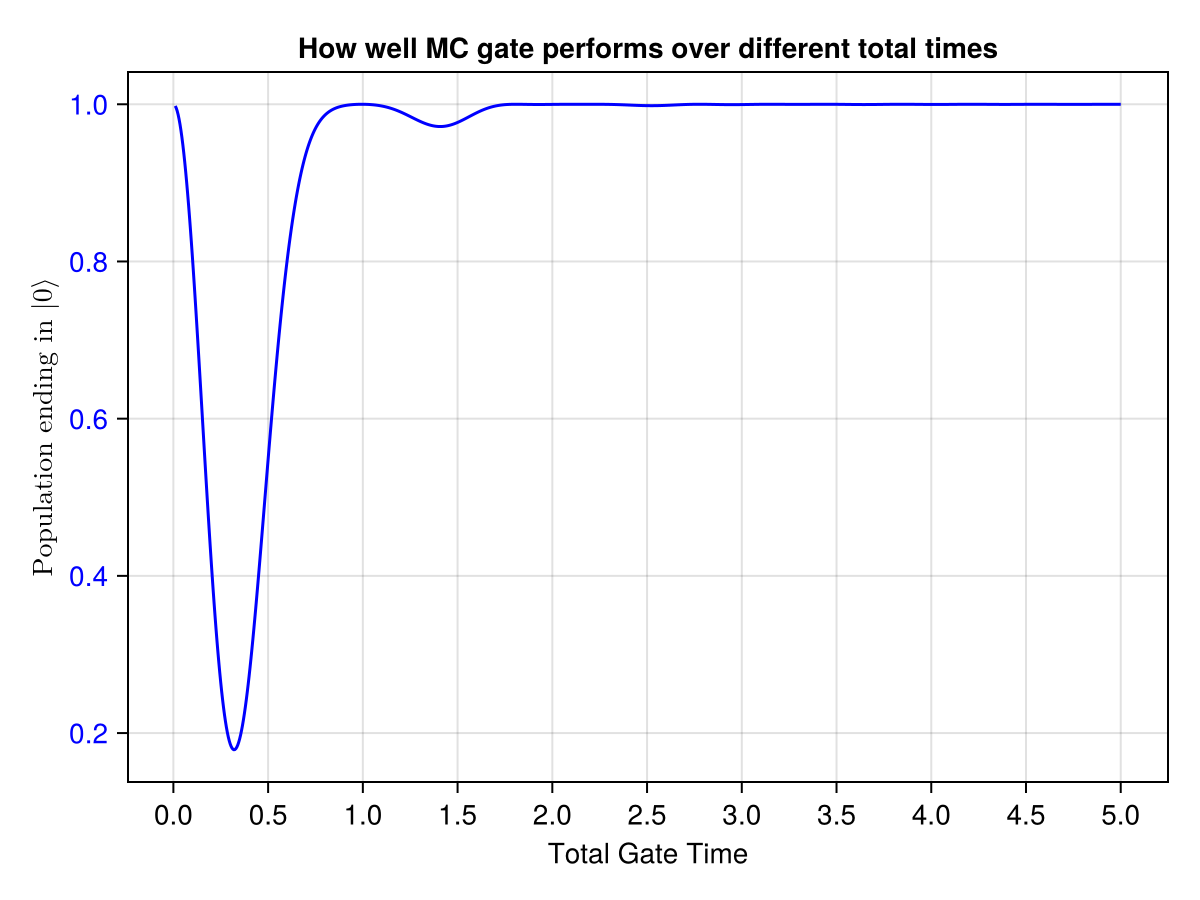

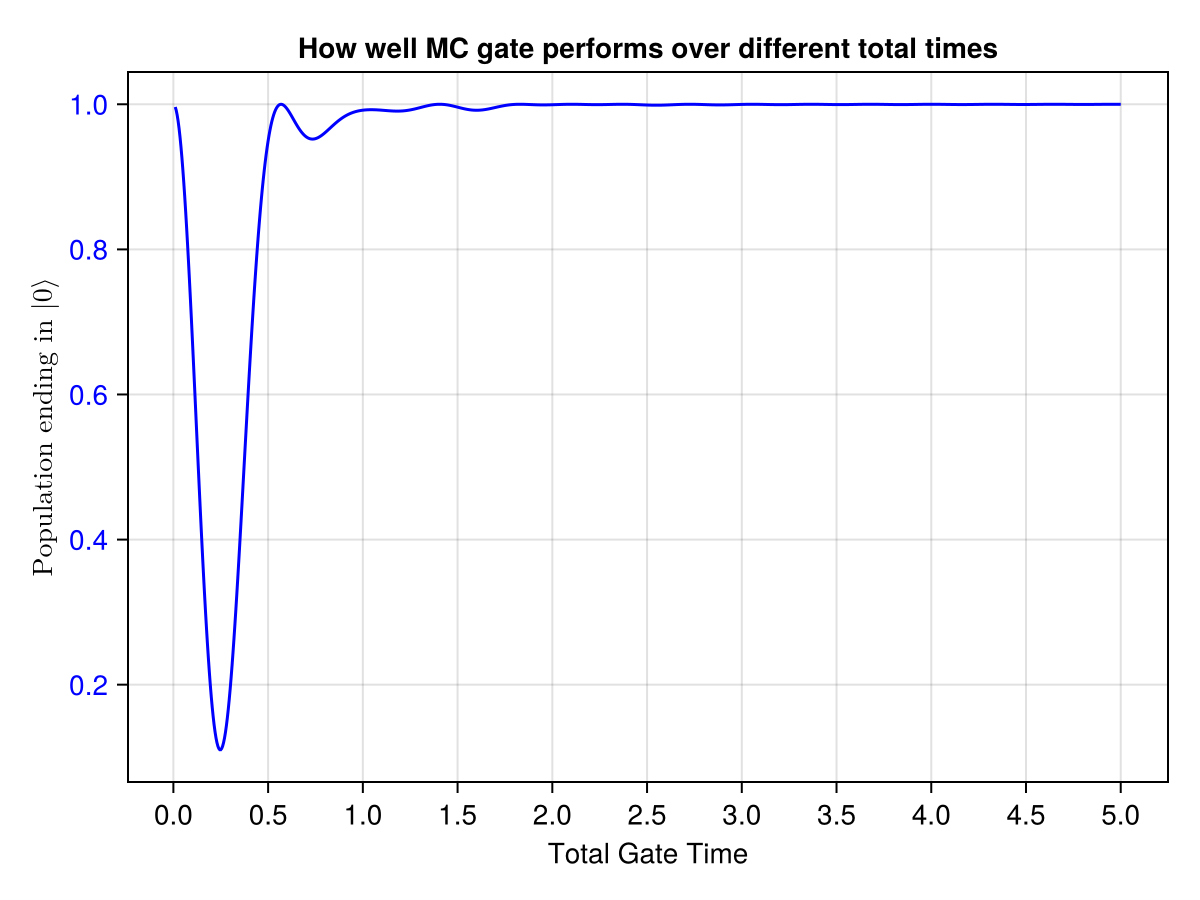

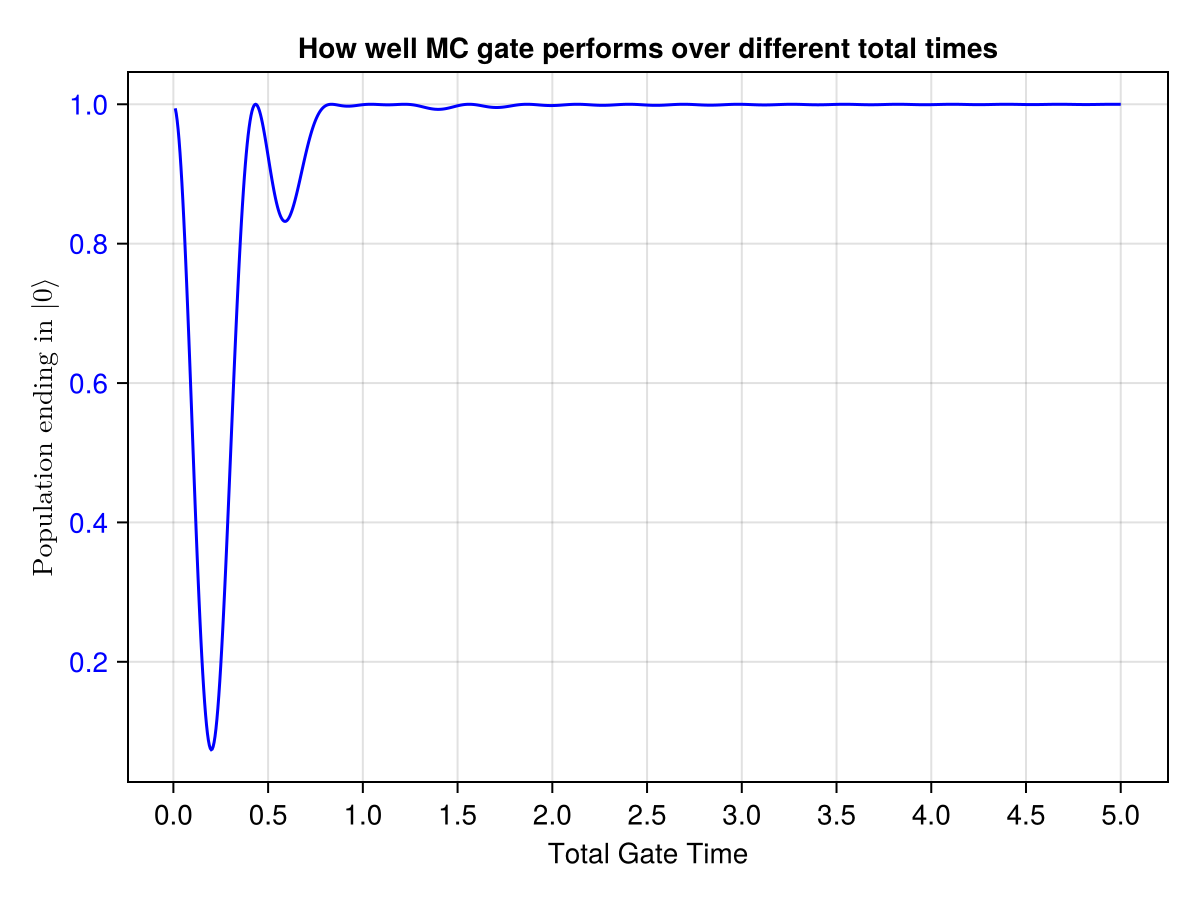

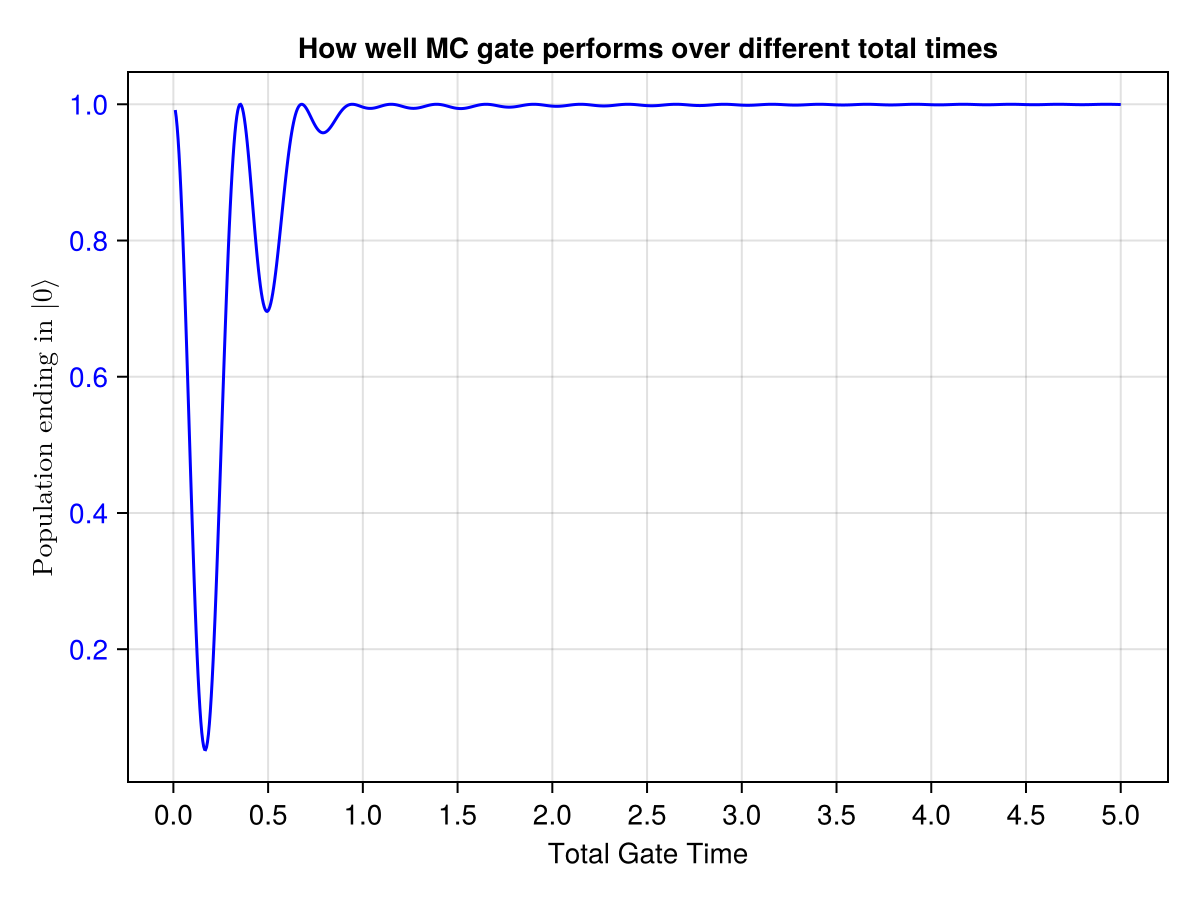

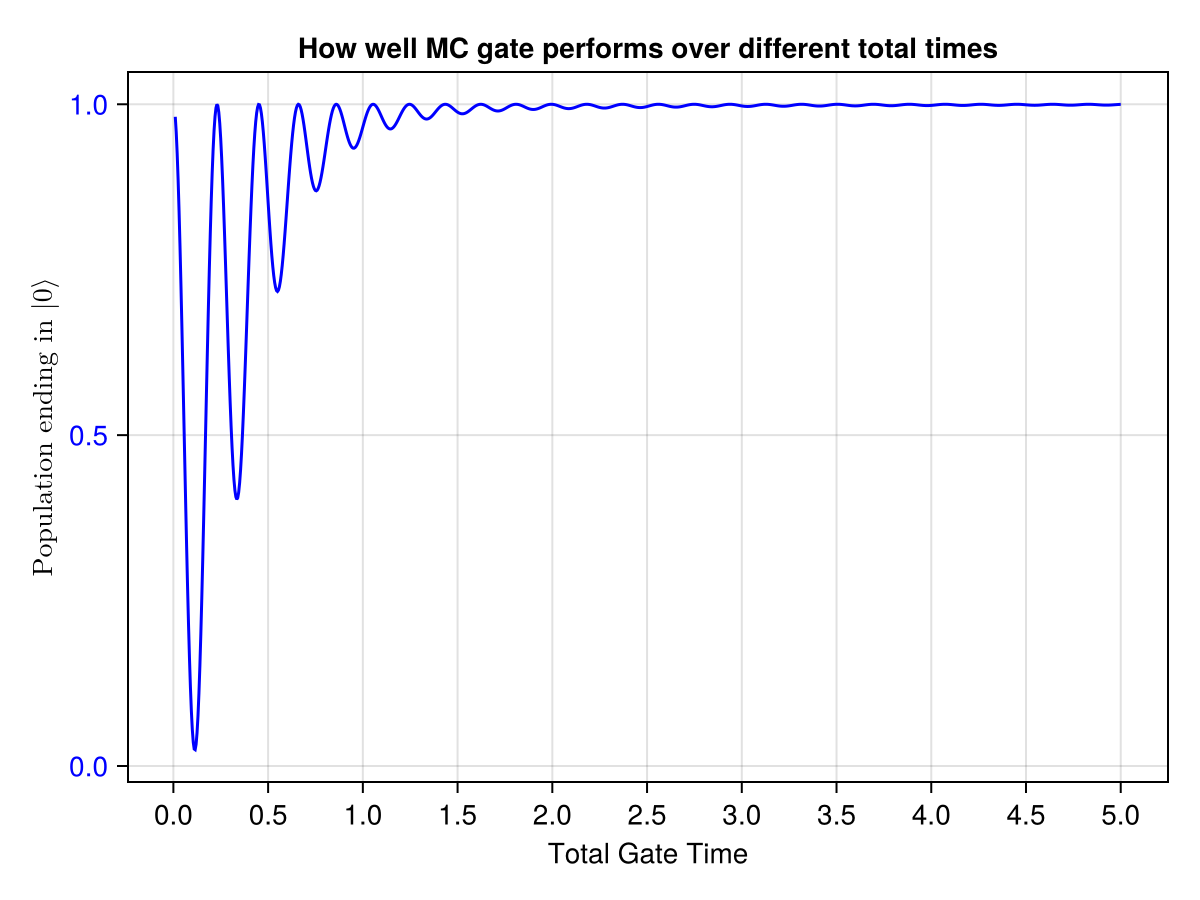

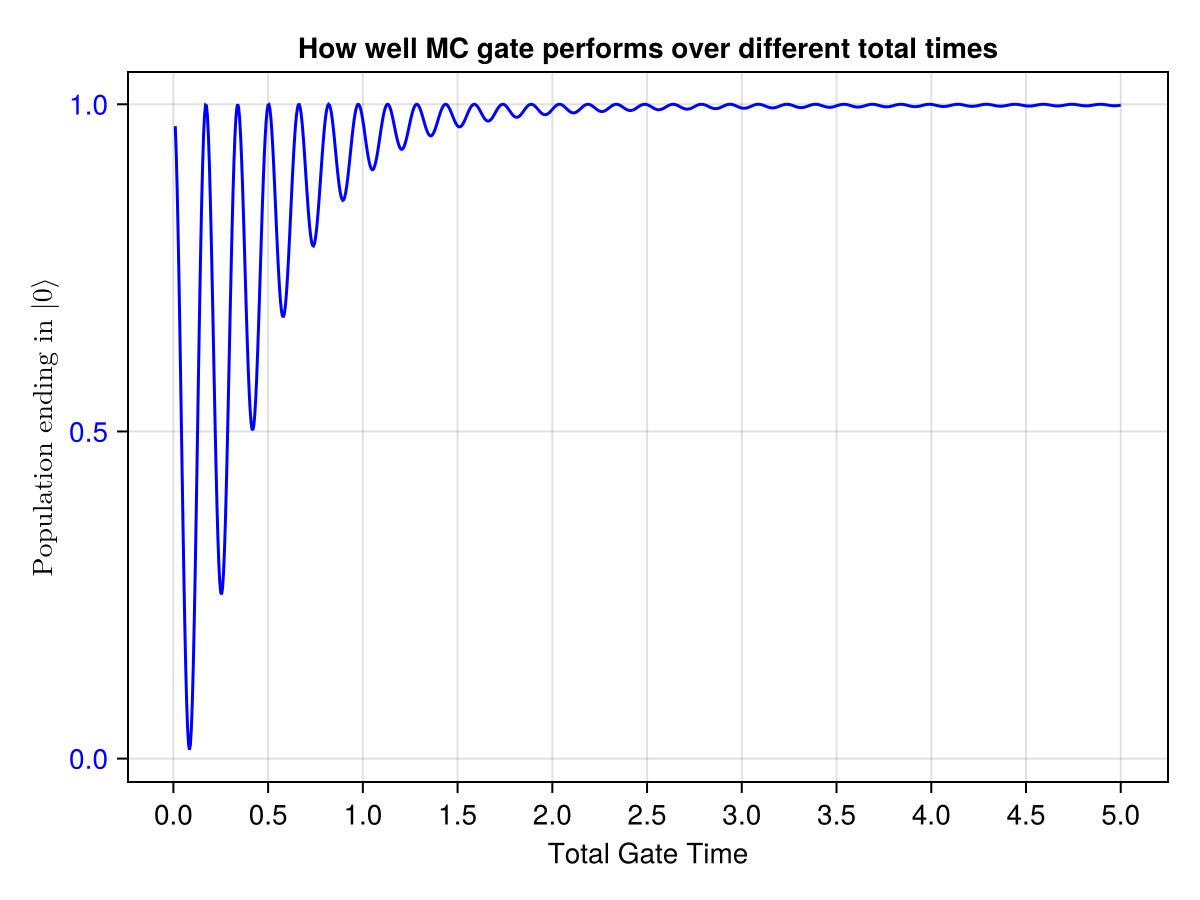

In [15]:
using QuantumOptics

iterations = 1000
tmin = 0.01
tmax = 5
Ts = range(tmin, tmax, iterations)

for strength_multiplier in [0.5, 1, 1.33, 1.66, 2, 3, 4]
    function ending_population(T::Real) 
        (tout, psi_t, H), (Δ, Ω, ϕ) = mattChow(T, strength_multiplier)
        return abs2(psi_t[end][2])
    end

    # function ending_phase(T::Real) 
    #     (tout, psi_t, H), (Δ, Ω, ϕ) = mattChow(T, 2)
    #     return angle(psi_t[end][2])
    # end

    # plotting
    fig = Figure()
    ax1 = Axis(fig[1, 1], yticklabelcolor = :blue,

        title = "How well MC gate performs over different total times",
        xlabel = "Total Gate Time",
        ylabel = L"Population ending in $|0\rangle$",
        xticks = (0:0.5:tmax)
    )
    # ax2 = Axis(fig[1, 1], yticklabelcolor = :red, yaxisposition = :right,
    #     # yticks = sin.([-1, 0, 1]), ["-π", "-π/2", "0", "π/2", "π"]
    #     yticks = (sin.([-π/2, 0, π/2]), [L"$-\sin \pi/2$", "0", L"$\sin \pi/2$",]),
    #     ylabel = L"$\sin$ of phase accumulated on $|0\rangle$",
    # )

    # hidespines!(ax2)
    # hidexdecorations!(ax2)

    lines!(ax1, Ts, ending_population, color = :blue)
    # lines!(ax2, Ts, x -> sin.(ending_phase(x)), color = :red)
    display(fig)
end

Now the real question is "why is this happening?"